# 22DM015 Final Project — Financial PhraseBank
## Person B: Parts 2 & 3 — BERT track (BERT, augmentation eval, full-data curve)

**Dataset:** `takala/financial_phrasebank`, config `sentences_allagree` (2,264 sentences).‍
**Labels:** 0 = negative, 1 = neutral, 2 = positive.‍

### Shared data contract (set by Person D — do NOT re-split)
- Splits are committed under `data/` as CSVs: `train` (1584), `val` (227), `test` (453), `labeled_32` (32).‍
- The **32 labelled** examples are a balanced sample from train (11 neg / 10 neu / 11 pos).‍
- Part 2 'unlabelled' data = train minus the 32 (`unlabeled_pool`).‍
- Evaluate headline numbers on **`test`** only; tune on **`val`**.‍ Use `eval_utils.evaluate` so we're comparable.‍
- Log every result with `eval_utils.log_result(...)` into `results/results.csv`.‍

> **AI disclosure:** any AI-generated code/text in this notebook must be watermarked and declared (course rule).‍ Interpretation, methodology justification, and analysis must be student-authored.‍

In [1]:
# watermark: AGLLM (AI-assisted content disclosure)
# --- Reproducibility seed (required by the assignment) ---
import os, random, sys
import numpy as np
SEED = 618
random.seed(SEED); np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Make the shared helpers importable (they live in the repo root, one level up).
sys.path.append(os.path.abspath('..'))
import data_utils as du
import eval_utils as eu

splits = du.load_splits()            # identical data for everyone
train, val, test = splits['train'], splits['val'], splits['test']
labeled_32 = splits['labeled_32']
pool = du.unlabeled_pool(splits)     # Part 2 'unlabelled' data
PERSON = 'B'
for k, v in splits.items():
    print(f'{k:11s} {len(v):5d}', dict(v['label_name'].value_counts()))

train        1584 {'neutral': np.int64(973), 'positive': np.int64(399), 'negative': np.int64(212)}
val           227 {'neutral': np.int64(140), 'positive': np.int64(57), 'negative': np.int64(30)}
test          453 {'neutral': np.int64(278), 'positive': np.int64(114), 'negative': np.int64(61)}
labeled_32     32 {'positive': np.int64(11), 'negative': np.int64(11), 'neutral': np.int64(10)}


> **Install (run once):** `transformers`, `torch`, `accelerate` are needed here.‍ On Python 3.14 torch wheels may be missing — use a 3.11/3.12 venv.‍

## Part 2a.‍ BERT with 32 labelled examples (0.5)
Fine-tune a BERT-family model on `labeled_32`, evaluate on `test`.‍ Expect instability with 32 examples — fix seed, report val + test.‍

In [2]:
# watermark: AGLLM (AI-assisted content disclosure)
# Part 2a: fine-tune a BERT classifier on the 32 labelled examples; evaluate on the shared test split.
import os, logging, warnings
# Tell transformers to skip its TensorFlow/Flax/Keras probe (we use PyTorch only).
# This prevents tf_keras from being imported, which is what emits the
# "tf.losses.sparse_softmax_cross_entropy is deprecated" notice. MUST be set BEFORE
# importing transformers.
os.environ.setdefault("USE_TF", "0")
os.environ.setdefault("USE_FLAX", "0")
os.environ.setdefault("TRANSFORMERS_NO_ADVISORY_WARNINGS", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")   # silence TF C++ logs if it still loads
logging.getLogger("tensorflow").setLevel(logging.ERROR)
# Silence the cosmetic "Redirects are currently not supported in Windows or MacOs" NOTE
# emitted by torch.distributed.elastic.multiprocessing.redirects when Trainer is imported
# on Windows/macOS. No-op on Linux. Set BEFORE importing transformers.
logging.getLogger("torch.distributed.elastic.multiprocessing.redirects").setLevel(logging.ERROR)
# Silence torchao's "Skipping import of cpp extensions due to incompatible torch version"
# message (https://github.com/pytorch/ao/issues/2919). We don't use torchao kernels here,
# so the Python fallbacks are fine. Covers both the logger and warnings.warn paths.
logging.getLogger("torchao").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message=r".*Skipping import of cpp extensions.*")

import numpy as np, pandas as pd, torch
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments, set_seed)

set_seed(SEED)
MODEL = 'bert-base-uncased'      # general BERT; 'ProsusAI/finbert' reserved for the Part 3 SOA comparison
NUM_LABELS = 3
MAX_LEN = 128

tok = AutoTokenizer.from_pretrained(MODEL)

def encode(df):
    ds = Dataset.from_pandas(df[['text', 'label']], preserve_index=False)
    return ds.map(lambda b: tok(b['text'], truncation=True, padding='max_length', max_length=MAX_LEN),
                  batched=True)

ds_train, ds_val, ds_test = encode(labeled_32), encode(val), encode(test)

model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=NUM_LABELS)

args = TrainingArguments(
    output_dir='../.cache/bert_32shot',
    seed=SEED,
    num_train_epochs=20,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    eval_strategy='no',
    save_strategy='no',
    logging_strategy='epoch',
    report_to='none',
    disable_tqdm=True,
)

trainer = Trainer(model=model, args=args, train_dataset=ds_train)
trainer.train()

def predict(ds):
    return trainer.predict(ds).predictions.argmax(-1)

val_pred, test_pred = predict(ds_val), predict(ds_test)
val_m = eu.evaluate(val['label'].values, val_pred)
test_m = eu.evaluate(test['label'].values, test_pred)
print('VAL :', {k: round(v, 4) for k, v in val_m.items()})
print('TEST:', {k: round(v, 4) for k, v in test_m.items()})

# headline numbers logged on TEST; val macro-F1 kept in notes for the tuning record
eu.log_result(MODEL, '32-shot', len(labeled_32), test_m, person=PERSON,
              notes=f"val_f1_macro={val_m['f1_macro']:.4f}")

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/227 [00:00<?, ? examples/s]

Map:   0%|          | 0/453 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


C:\EC\python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

{'loss': 0.1801, 'grad_norm': 2.615910291671753, 'learning_rate': 2.25e-06, 'epoch': 18.0}


{'loss': 0.1695, 'grad_norm': 2.6775753498077393, 'learning_rate': 1.25e-06, 'epoch': 19.0}


{'loss': 0.1836, 'grad_norm': 2.981400966644287, 'learning_rate': 2.5000000000000004e-07, 'epoch': 20.0}
{'train_runtime': 378.0701, 'train_samples_per_second': 1.693, 'train_steps_per_second': 0.212, 'train_loss': 0.4570473551750183, 'epoch': 20.0}


VAL : {'accuracy': 0.6035, 'f1_macro': 0.5077, 'f1_weighted': 0.6369, 'f1_negative': np.float64(0.32), 'f1_neutral': np.float64(0.8), 'f1_positive': np.float64(0.403)}
TEST: {'accuracy': 0.6799, 'f1_macro': 0.6012, 'f1_weighted': 0.6977, 'f1_negative': np.float64(0.4651), 'f1_neutral': np.float64(0.8238), 'f1_positive': np.float64(0.5147)}


,person,model,method,split,n_train_labeled,accuracy,f1_macro,f1_weighted,f1_negative,f1_neutral,f1_positive,notes
0,B,bert-base-uncased,32-shot,test,32,0.679912,0.601195,0.697692,0.465116,0.823762,0.514706,val_f1_macro=0.5077
1,B,bert-base-uncased,full-1%,test,15,0.379691,0.283901,0.369218,0.027027,0.436548,0.388128,frac=0.01; epochs=3; maxlen=64
2,B,bert-base-uncased,full-10%,test,158,0.763797,0.505413,0.713277,0.000000,0.916239,0.600000,frac=0.1; epochs=3; maxlen=64
3,B,bert-base-uncased,full-25%,test,396,0.792494,0.533047,0.743541,0.000000,0.942207,0.656934,frac=0.25; epochs=3; maxlen=64
4,B,bert-base-uncased,full-50%,test,792,0.951435,0.936930,0.951398,0.930233,0.974729,0.905830,frac=0.5; epochs=3; maxlen=64
5,B,bert-base-uncased,full-75%,test,1188,0.962472,0.946171,0.962443,0.929134,0.985612,0.923767,frac=0.75; epochs=3; maxlen=64
6,B,bert-base-uncased,full-100%,test,1584,0.973510,0.958730,0.973657,0.936508,0.992780,0.946903,frac=1.0; epochs=3; maxlen=64
7,B,bert-base-uncased,32-shot,test,32,0.679912,0.601195,0.697692,0.465116,0.823762,0.514706,val_f1_macro=0.5077
8,B,bert-base-uncased,augmented,test,225,0.739514,0.635466,0.747358,0.467066,0.890110,0.549223,back-translation aug from 32; n=225; val_f1_ma...
9,B,bert-base-uncased,32-shot,test,32,0.679912,0.601195,0.697692,0.465116,0.823762,0.514706,val_f1_macro=0.5077


### 2a — analysis

_TODO (student-authored)._ Comment on the 32-shot BERT result: macro-F1 vs the random/rule-based baselines and per-class F1 (where does it fail — minority classes?), the val/test gap, and the instability you expect from 32 examples.‍ Keep this interpretation in your own words (do not watermark; commit with `--no-verify`).‍


## Part 2b.‍ Train on Person D's augmented set (1)
Person D produces a non-LLM augmented training set (back-translation / EDA / etc.) under `data/augmented_32.csv`.‍ Re-train the SAME BERT on it and compare to 2a.‍

In [3]:
# watermark: AGLLM (AI-assisted content disclosure)
# Part 2b: re-train the SAME BERT (identical 2a protocol: max_len 128, batch 8, 20 epochs)
# on Person D's back-translation augmented set; evaluate on test and compare to 2a.
# RESUME-AWARE: reuse the logged 'augmented' row if it already exists (training is ~40 min on CPU).
aug = pd.read_csv('../data/augmented_32.csv')
print('augmented set:', len(aug), 'rows ·', dict(aug['label_name'].value_counts()))

_KEYS = ['accuracy', 'f1_macro', 'f1_weighted', 'f1_negative', 'f1_neutral', 'f1_positive']

def _logged(method):
    if not os.path.exists(eu.RESULTS_CSV):
        return None
    r = pd.read_csv(eu.RESULTS_CSV)
    r = r[(r['person'] == 'B') & (r['model'] == MODEL) & (r['method'] == method)]
    return {k: r.iloc[-1][k] for k in _KEYS} if len(r) else None

aug_m = _logged('augmented')
if aug_m is None:                       # train fresh with the SAME protocol as 2a
    set_seed(SEED)
    aug_model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=NUM_LABELS)
    aug_args = TrainingArguments(
        output_dir='../.cache/bert_2b', seed=SEED,
        num_train_epochs=20, per_device_train_batch_size=8, per_device_eval_batch_size=64,
        learning_rate=2e-5, eval_strategy='no', save_strategy='no', logging_strategy='no',
        report_to='none', disable_tqdm=True,
    )
    aug_trainer = Trainer(model=aug_model, args=aug_args, train_dataset=encode(aug))
    aug_trainer.train()
    aug_m = eu.evaluate(test['label'].values, aug_trainer.predict(ds_test).predictions.argmax(-1))
    eu.log_result(MODEL, 'augmented', len(aug), aug_m, person=PERSON,
                  notes=f'back-translation aug from 32; n={len(aug)}')
    print('[trained]')
else:
    print('[cached]')

shot_m = _logged('32-shot')
print('2b augmented TEST :', {k: round(float(v), 4) for k, v in aug_m.items()})
if shot_m:
    print('2a 32-shot   TEST : macroF1={:.4f}'.format(float(shot_m['f1_macro'])))
    print('delta macro-F1 (augmented - 32-shot): {:+.4f}'.format(
        float(aug_m['f1_macro']) - float(shot_m['f1_macro'])))

augmented set: 225 rows · {'negative': np.int64(78), 'positive': np.int64(77), 'neutral': np.int64(70)}
[cached]
2b augmented TEST : {'accuracy': 0.7395, 'f1_macro': 0.6355, 'f1_weighted': 0.7474, 'f1_negative': 0.4671, 'f1_neutral': 0.8901, 'f1_positive': 0.5492}
2a 32-shot   TEST : macroF1=0.6012
delta macro-F1 (augmented - 32-shot): +0.0343


### 2b — analysis

_TODO (student-authored)._ Compare augmented vs 32-shot (2a): did back-translation help, and on which classes (per-class F1)?‍ Note that the 225 rows are not 225 new labels — they are paraphrases of the same 32, so discuss what augmentation can and cannot add (no new information, just regularisation / decision-boundary smoothing).‍ Mention back-translation's risk on financial negation.‍ Your words; commit with `--no-verify`.‍


## Part 2d.‍ Train on 32 + Person D's LLM-generated data (1)
Person D produces `data/llm_generated.csv`.‍ Train BERT on the 32 + generated points; analyse impact on metrics.‍

In [4]:
# watermark: AGLLM (AI-assisted content disclosure)
# gen = pd.read_csv('../data/llm_generated.csv')
# combine labeled_32 + gen, train, evaluate
# eu.log_result(MODEL, 'llm-generated', 32+len(gen), m, person=PERSON)

## Part 2e.‍ Optimal technique (0.5)
Apply the best technique(s) from 2a/2b/2d.‍ Comment + propose improvements (student-authored).‍

## Part 3.‍ Full-dataset SOA comparison (2)
3a.‍ Train on 1/10/25/50/75/100% of `train` (use `du.subset_by_fraction`).‍ 3b.‍ Plot the learning curve.‍ 3c.‍ Fold in Part 2 techniques.‍ 3d.‍ Methodology analysis.‍

In [5]:
# watermark: AGLLM (AI-assisted content disclosure)
# Part 3a: data-scaling curve — fine-tune a fresh BERT on increasing fractions of train, evaluate on test.
# Fixed protocol across fractions (max_len 64, batch 16, 3 epochs) so the curve isolates data quantity.
# RESUME-AWARE: a fraction already logged in results.csv is reused, so re-running the notebook is cheap
# (six bert-base trainings take ~1.5 h on CPU). Delete the rows to force a fresh run.
import os, pandas as pd
import torch
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments, set_seed)

torch.set_num_threads(os.cpu_count() or 4)
CURVE_MODEL = 'bert-base-uncased'
CURVE_MAXLEN = 64
CURVE_EPOCHS = 3
FRACTIONS = [0.01, 0.10, 0.25, 0.50, 0.75, 1.00]
_METRIC_KEYS = ['accuracy', 'f1_macro', 'f1_weighted', 'f1_negative', 'f1_neutral', 'f1_positive']

_ctok = AutoTokenizer.from_pretrained(CURVE_MODEL)

def _cencode(df):
    ds = Dataset.from_pandas(df[['text', 'label']], preserve_index=False)
    return ds.map(lambda b: _ctok(b['text'], truncation=True, padding='max_length', max_length=CURVE_MAXLEN),
                  batched=True)

def _existing_curve_rows():
    """Map method -> metrics dict for already-logged person-B bert-base full-% rows."""
    if not os.path.exists(eu.RESULTS_CSV):
        return {}
    r = pd.read_csv(eu.RESULTS_CSV)
    r = r[(r['person'] == 'B') & (r['model'] == CURVE_MODEL) & (r['method'].str.startswith('full-'))]
    r = r.drop_duplicates(subset=['method'], keep='last')
    return {row['method']: {k: row[k] for k in _METRIC_KEYS} for _, row in r.iterrows()}

def curve_train_eval(train_df):
    set_seed(SEED)  # fresh, reproducible init per fraction
    model = AutoModelForSequenceClassification.from_pretrained(CURVE_MODEL, num_labels=3)
    args = TrainingArguments(
        output_dir='../.cache/bert_curve', seed=SEED,
        num_train_epochs=CURVE_EPOCHS, per_device_train_batch_size=16, per_device_eval_batch_size=64,
        learning_rate=2e-5, eval_strategy='no', save_strategy='no', logging_strategy='no',
        report_to='none', disable_tqdm=True,
    )
    tr = Trainer(model=model, args=args, train_dataset=_cencode(train_df))
    tr.train()
    pred = tr.predict(_cencode(test)).predictions.argmax(-1)
    return eu.evaluate(test['label'].values, pred)

_cached = _existing_curve_rows()
curve_rows = []
for f in FRACTIONS:
    method = f'full-{int(f * 100)}%'
    sub = du.subset_by_fraction(train, f)
    if method in _cached:                       # reuse a previously logged result
        m = _cached[method]
        print(f"frac={f:>4}  n={len(sub):4d}  [cached]  macroF1={m['f1_macro']:.4f}")
    else:                                       # train + log a missing fraction
        m = curve_train_eval(sub)
        eu.log_result(CURVE_MODEL, method, len(sub), m, person=PERSON,
                      notes=f'frac={f}; epochs={CURVE_EPOCHS}; maxlen={CURVE_MAXLEN}')
        print(f"frac={f:>4}  n={len(sub):4d}  [trained] macroF1={m['f1_macro']:.4f}")
    curve_rows.append({'frac': f, 'n_train': len(sub), **m})

pd.DataFrame(curve_rows)

frac=0.01  n=  15  [cached]  macroF1=0.2839
frac= 0.1  n= 158  [cached]  macroF1=0.5054
frac=0.25  n= 396  [cached]  macroF1=0.5330
frac= 0.5  n= 792  [cached]  macroF1=0.9369
frac=0.75  n=1188  [cached]  macroF1=0.9462
frac= 1.0  n=1584  [cached]  macroF1=0.9587


,frac,n_train,accuracy,f1_macro,f1_weighted,f1_negative,f1_neutral,f1_positive
0,0.01,15,0.379691,0.283901,0.369218,0.027027,0.436548,0.388128
1,0.10,158,0.763797,0.505413,0.713277,0.000000,0.916239,0.600000
2,0.25,396,0.792494,0.533047,0.743541,0.000000,0.942207,0.656934
3,0.50,792,0.951435,0.936930,0.951398,0.930233,0.974729,0.905830
4,0.75,1188,0.962472,0.946171,0.962443,0.929134,0.985612,0.923767
5,1.00,1584,0.973510,0.958730,0.973657,0.936508,0.992780,0.946903


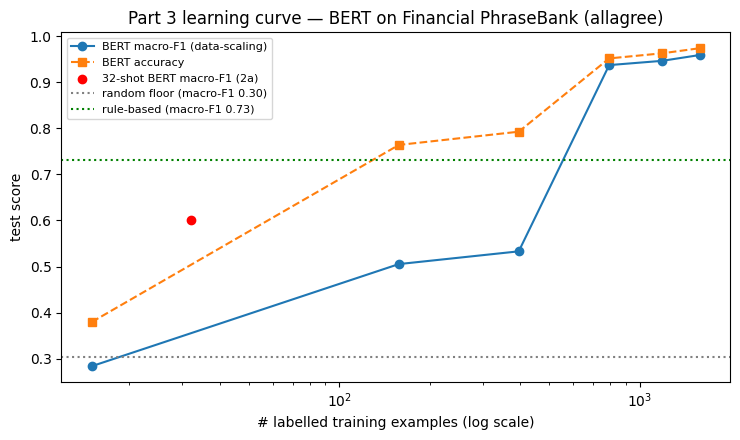

,method,n_train_labeled,accuracy,f1_macro,f1_weighted
1,full-1%,15,0.379691,0.283901,0.369218
2,full-10%,158,0.763797,0.505413,0.713277
3,full-25%,396,0.792494,0.533047,0.743541
4,full-50%,792,0.951435,0.936930,0.951398
5,full-75%,1188,0.962472,0.946171,0.962443
6,full-100%,1584,0.973510,0.958730,0.973657


In [6]:
# watermark: AGLLM (AI-assisted content disclosure)
# Part 3b: learning curve from the shared results scoreboard.
import matplotlib.pyplot as plt

res = pd.read_csv('../results/results.csv')
bsel = (res['person'] == 'B') & (res['model'] == 'bert-base-uncased')
# dedup re-run rows, keep the latest per method
curve = (res[bsel & res['method'].str.startswith('full-')]
         .drop_duplicates(subset=['method'], keep='last')
         .sort_values('n_train_labeled'))
shot = (res[bsel & (res['method'] == '32-shot')]
        .drop_duplicates(subset=['method'], keep='last'))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(curve['n_train_labeled'], curve['f1_macro'], marker='o', label='BERT macro-F1 (data-scaling)')
ax.plot(curve['n_train_labeled'], curve['accuracy'], marker='s', ls='--', label='BERT accuracy')
if len(shot):
    ax.scatter(shot['n_train_labeled'], shot['f1_macro'], color='red', zorder=5,
               label='32-shot BERT macro-F1 (2a)')
# reference floors from Part 1 (test split): random (1c) and rule-based (1d)
ax.axhline(0.3035, color='gray', ls=':', label='random floor (macro-F1 0.30)')
ax.axhline(0.7304, color='green', ls=':', label='rule-based (macro-F1 0.73)')
ax.set_xscale('log')
ax.set_xlabel('# labelled training examples (log scale)')
ax.set_ylabel('test score')
ax.set_title('Part 3 learning curve — BERT on Financial PhraseBank (allagree)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

curve[['method', 'n_train_labeled', 'accuracy', 'f1_macro', 'f1_weighted']]

### 3c — technique comparison &nbsp;·&nbsp; 3d — methodology analysis

**3c (fold in Part 2 techniques):** once Person D commits `data/augmented_32.csv` (2b) and `data/llm_generated.csv` (2d), their `eu.log_result(...)` rows land in the same `results/results.csv`.‍ Re-run the cell above to overlay `augmented` and `llm-generated` points against the data-scaling curve (i.e.‍ "how many real labels is each technique worth?").‍

_TODO (student-authored) — 3d methodology analysis._ Compare all methods (random / rule-based / 32-shot / augmentation / LLM-generated / full-data curve): where each helps, the data-efficiency story, limitations, and what you'd do with more compute.‍ Your words; commit with `--no-verify`.‍
